# 09 — From manual NumPy to PyTorch: prove the framework is doing the same mathematics

Frameworks should arrive **after** first-principles understanding.

## What you should learn
- `requires_grad` stores gradient requirements;
- `.backward()` performs reverse-mode autodiff;
- `nn.Module` organizes parameters and forward computation;
- optimizers automate parameter updates, not the mathematical objective;
- manual and PyTorch gradients should agree numerically.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
torch.manual_seed(42)
print('torch version:',torch.__version__,'device: cpu')


torch version: 2.14.0+cpu device: cpu


## 1. Scalar equivalence check


In [2]:
x=2.0;w=-.5;b=.1;y=5.0
# manual squared-error derivative
pred=w*x+b;manual_dw=2*(pred-y)*x;manual_db=2*(pred-y)
xt=torch.tensor(x);wt=torch.tensor(w,requires_grad=True);bt=torch.tensor(b,requires_grad=True);yt=torch.tensor(y)
pt=wt*xt+bt;loss=(pt-yt)**2;loss.backward()
print('manual:',manual_dw,manual_db)
print('torch :',wt.grad.item(),bt.grad.item())


manual: -23.6 -11.8
torch : -23.600000381469727 -11.800000190734863


## 2. Real digits with `nn.Module`


In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
d=load_digits();m=np.isin(d.target,[0,1]);X=d.data[m]/16.;y=(d.target[m]==1).astype(np.float32).reshape(-1,1)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
Xtr_t=torch.tensor(Xtr,dtype=torch.float32);ytr_t=torch.tensor(ytr);Xte_t=torch.tensor(Xte,dtype=torch.float32)
class Net(nn.Module):
    def __init__(self):
        super().__init__();self.fc1=nn.Linear(64,8);self.act=nn.Tanh();self.fc2=nn.Linear(8,1)
    def forward(self,x):return self.fc2(self.act(self.fc1(x)))
model=Net();criterion=nn.BCEWithLogitsLoss();opt=torch.optim.Adam(model.parameters(),lr=.03);losses=[]
for ep in range(250):
    opt.zero_grad();logits=model(Xtr_t);L=criterion(logits,ytr_t);L.backward();opt.step();losses.append(L.item())
with torch.no_grad():probs=torch.sigmoid(model(Xte_t)).numpy();acc=accuracy_score(yte.astype(int),(probs>=.5).astype(int))
print('test accuracy:',acc)


test accuracy: 1.0


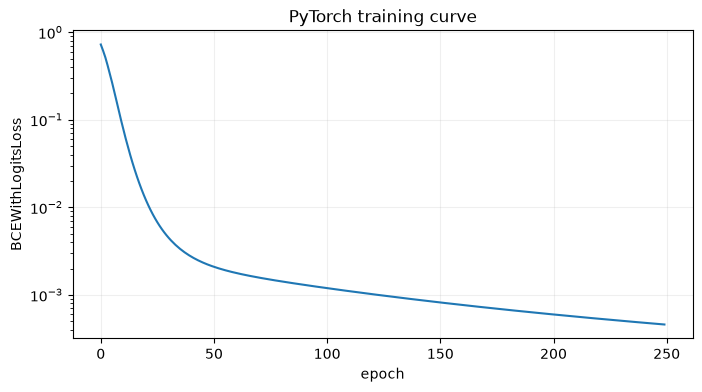

In [4]:
plt.figure(figsize=(8,4));plt.plot(losses);plt.yscale('log');plt.xlabel('epoch');plt.ylabel('BCEWithLogitsLoss');plt.title('PyTorch training curve');plt.grid(alpha=.2);plt.show()


## 3. Inspect gradients instead of treating autograd as magic


In [5]:
model.zero_grad();one_logits=model(Xtr_t[:1]);one_loss=criterion(one_logits,ytr_t[:1]);one_loss.backward()
rows=[]
for name,p in model.named_parameters():rows.append([name,tuple(p.shape),p.grad.norm().item(),p.detach().norm().item()])
pd = __import__('pandas')
pd.DataFrame(rows,columns=['parameter','shape','gradient norm','parameter norm'])


,parameter,shape,gradient norm,parameter norm
0,fc1.weight,"(8, 64)",0.000006,9.678921
1,fc1.bias,"(8,)",0.000002,1.349442
2,fc2.weight,"(1, 8)",0.001100,2.777977
3,fc2.bias,"(1,)",0.000389,0.035034


## Inference / insight
PyTorch removes bookkeeping, not understanding. The same quantities still exist: pre-activations, activations, logits, loss, gradients, and updates. Debugging a framework model becomes much easier when you can map each abstraction back to the manual notebooks.
